In [1]:
import importlib
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import strategy as strat_module

# Game parameters (matches assignment: 7 days × 24 hourly queries)
N_PERIODS = 168
N_TEAMS   = 5    # us + 4 competitors

# Competitive demand: P(buy) = sigmoid(a - b·our_price + c·mean_comp_price)
# Captures that higher competitor prices shift customers toward us
A, B, C = 2.5, 0.05, 0.02

def p_buy(our_price, comp_prices):
    x = A - B * our_price + C * float(np.mean(comp_prices))
    return 1.0 / (1.0 + np.exp(-x))

def clear_data():
    for f in ["test_historical_demands.csv", "test_historical_prices.csv"]:
        if os.path.exists(f):
            os.remove(f)

def run_sim(strategy_fn):
    """Run one full game simulation. strategy_fn() -> price."""
    clear_data()
    revenues, prices_log = [], []

    for _ in range(N_PERIODS):
        p  = float(np.clip(strategy_fn(), 1.0, 100.0))
        cp = np.random.uniform(20, 80, N_TEAMS - 1)  # competitors price randomly

        bought = int(np.random.binomial(1, p_buy(p, cp)))

        with open("test_historical_demands.csv", "a") as f:
            f.write(f"{p},{bought}\n")
        with open("test_historical_prices.csv", "a") as f:
            f.write(",".join(map(str, [p] + list(cp))) + "\n")

        revenues.append(p * bought)
        prices_log.append(p)

    return np.array(revenues), np.array(prices_log)

/Users/sabrina/Desktop/IEOR4601/venv/lib/python3.12/site-packages/sklearn/experimental/enable_hist_gradient_boosting.py:18: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


In [2]:
importlib.reload(strat_module)

print("Running strategy simulation...")
our_rev, our_prices = run_sim(strat_module.strategy)

print("Running baseline (fixed price = 50)...")
base_rev, _ = run_sim(lambda: 50.0)

# With A=2.5, B=0.05, C=0.02, competitors ~Uniform[20,80] (mean≈50):
# true optimal p* ≈ argmax p·sigmoid(2.5 - 0.05p + 0.02·50) ≈ 57

print(f"\nTotal revenue   — Strategy: {our_rev.sum():.1f}  |  Baseline p=50: {base_rev.sum():.1f}")
print(f"Mean rev/period — Strategy: {our_rev.mean():.2f}  |  Baseline p=50: {base_rev.mean():.2f}")
print(f"Mean price      — Strategy: {our_prices.mean():.2f}")
print(f"Buy rate        — Strategy: {(our_rev > 0).mean():.2f}  |  Baseline: {(base_rev > 0).mean():.2f}")

Running strategy simulation...
Running baseline (fixed price = 50)...

Total revenue   — Strategy: 6002.8  |  Baseline p=50: 5750.0
Mean rev/period — Strategy: 35.73  |  Baseline p=50: 34.23
Mean price      — Strategy: 54.90
Buy rate        — Strategy: 0.70  |  Baseline: 0.68


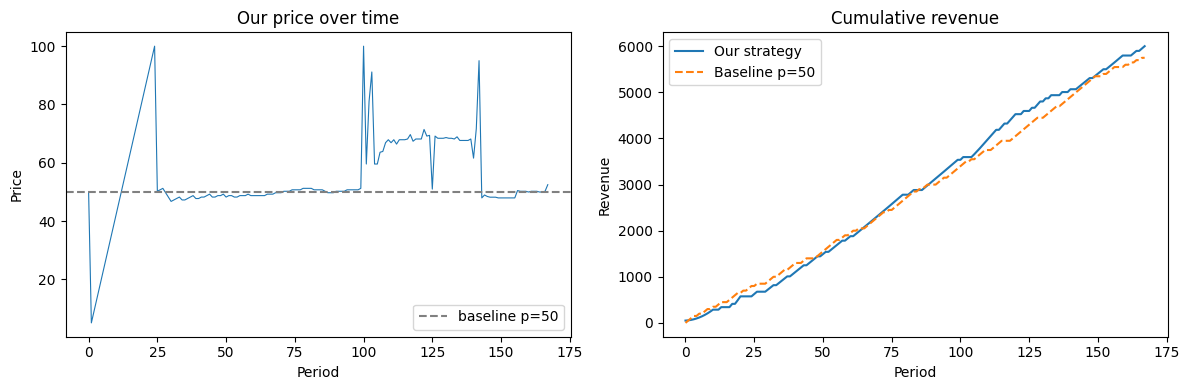

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Price trajectory
axes[0].plot(our_prices, linewidth=0.8)
axes[0].axhline(50, color='gray', linestyle='--', label='baseline p=50')
axes[0].set_title("Our price over time")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Price")
axes[0].legend()

# Cumulative revenue
axes[1].plot(np.cumsum(our_rev), label="Our strategy")
axes[1].plot(np.cumsum(base_rev), linestyle='--', label="Baseline p=50")
axes[1].set_title("Cumulative revenue")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Revenue")
axes[1].legend()

plt.tight_layout()
plt.show()